# Conditional volatility — `qufin.timeseries.garch`

Asset returns are *not* i.i.d. Their **mean** is nearly unpredictable, but their
**variance is highly predictable**: large moves cluster together (turbulent
weeks follow turbulent weeks), and calm begets calm. This is **volatility
clustering**, and the **GARCH** family is the canonical way to model it.

The generic mean/variance decomposition is

$$ r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal N(0,1) $$

so all the action is in how $\sigma_t^2$ — the **conditional variance** — evolves.

This package implements the workhorse specifications:

| Model | Equation (sketch) | Captures |
|---|---|---|
| **GARCH**(p,q) | $\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$ | clustering, persistence |
| **EGARCH** | $\log\sigma_t^2 = \omega + \alpha z_{t-1} + \gamma(|z_{t-1}|-E|z|) + \beta\log\sigma_{t-1}^2$ | leverage (log form, no positivity constraint) |
| **GJR** | $\sigma_t^2 = \omega + (\alpha + \gamma\,\mathbb 1_{\varepsilon_{t-1}<0})\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$ | leverage via a threshold |
| **EWMA** | $\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2$ | RiskMetrics, closed form |
| **DCC** | two-stage: GARCH per asset + dynamic correlation | time-varying co-movement |

**Roadmap**

0. Data — daily equity returns (real, with synthetic fallback)
1. Why GARCH? Volatility clustering and the ARCH-LM test
2. Fit GARCH(1,1) — conditional vol, persistence, unconditional level
3. *Provably recovers the truth* — simulate a known GARCH, refit, compare
4. The leverage effect — EGARCH and GJR
5. Forecasting the variance term structure
6. EWMA (RiskMetrics) and a model bake-off by AIC/BIC
7. DCC — time-varying correlation across assets
8. Hand-off — the `GARCHVolTargetStrategy`


## A note on scaling

Throughout we work with **returns in percent**, $r_t = 100\cdot\Delta\log p_t$.
Daily log-returns are $\mathcal O(0.01)$, which pushes $\omega$ down to
$\mathcal O(10^{-6})$ and makes the optimiser's job harder. Multiplying by 100
keeps every coefficient at a human-readable magnitude — this is standard
practice in the GARCH literature and changes nothing about the dynamics.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.timeseries import GARCH, EGARCH, GJR, EWMA, DCC
from qufin.timeseries import arch_lm, ljung_box, acf

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
ANNUAL = np.sqrt(252.0)


## 0. Data

We pull a small basket of liquid ETFs and convert closes to **percent
log-returns**. Offline, the loader falls back to a *synthetic* panel whose
returns are simulated from a GARCH(1,1) — so volatility clustering (and the
rest of the notebook's narrative) holds with or without a network.


In [2]:
TICKERS = ['SPY', 'TLT', 'GLD']

def _synthetic_garch_panel(n=5000, seed=7):
    """GARCH(1,1) returns per asset so clustering is visible offline."""
    rng = np.random.default_rng(seed)
    specs = [(0.02, 0.10, 0.87), (0.015, 0.06, 0.90), (0.03, 0.08, 0.88)]
    cols = []
    for (omega, alpha, beta) in specs:
        eps = np.zeros(n); s2 = np.empty(n); s2[0] = omega / (1 - alpha - beta)
        z = rng.standard_normal(n)
        for t in range(1, n):
            s2[t] = omega + alpha * eps[t-1]**2 + beta * s2[t-1]
            eps[t] = np.sqrt(s2[t]) * z[t]
        cols.append(eps)
    rets = np.column_stack(cols)
    # Light cross-asset correlation via a shared factor.
    rets += 0.3 * rng.standard_normal((n, 1))
    return rets

def load_returns(tickers=TICKERS, start='2005-01-01', end='2024-12-31'):
    """Return (rets[T,N] in percent, tickers). Falls back to synthetic."""
    try:
        import yfinance as yf
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][tickers].dropna()
        if len(close) > 1500:
            px = close.to_numpy(dtype='float64')
            return 100.0 * np.diff(np.log(px), axis=0), list(close.columns)
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic panel')
    return _synthetic_garch_panel(), list(tickers)

rets, tickers = load_returns()
spy = rets[:, 0]
print(f'panel: {rets.shape[0]} days x {rets.shape[1]} assets: {tickers}')
print(f'SPY daily return  mean={spy.mean():.4f}%  std={spy.std():.4f}%  '
      f'ann.vol={spy.std()*ANNUAL:.1f}%')


panel: 5031 days x 3 assets: ['SPY', 'TLT', 'GLD']
SPY daily return  mean=0.0390%  std=1.2005%  ann.vol=19.1%


## 1. Why GARCH? Volatility clustering

Two diagnostics make the case for a conditional-variance model:

* The **returns** themselves are close to white noise (Ljung-Box on $r_t$ is
  unremarkable), **but the squared returns are strongly autocorrelated** —
  today's magnitude predicts tomorrow's.
* **Engle's ARCH-LM test** regresses $r_t^2$ on its own lags; a tiny p-value
  rejects "no ARCH effects" and says a GARCH model is warranted.


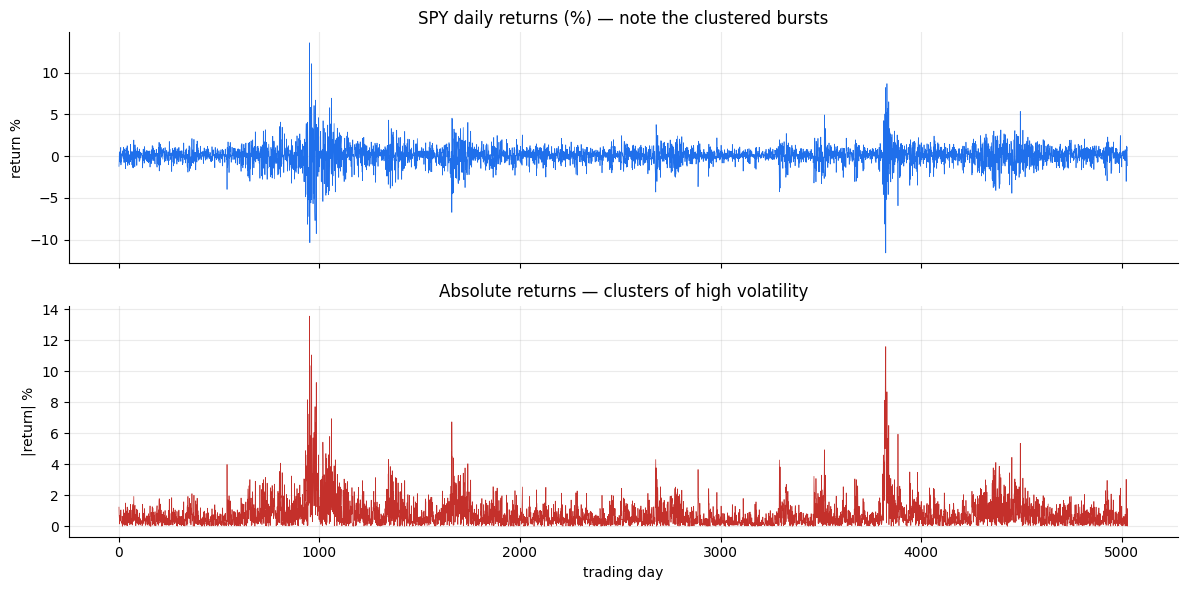

Ljung-Box on r_t   : Q=   150.0  p=6.23e-22  (weak serial corr in the level)
Ljung-Box on r_t^2 : Q=  6741.3  p=0.00e+00  (STRONG corr in magnitude)
Engle ARCH-LM (12) : LM=  1603.3  p=0.00e+00  -> reject "no ARCH"


In [3]:
fig, (axr, axs) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
axr.plot(spy, color='#1f6feb', lw=0.5); axr.set_title('SPY daily returns (%) — note the clustered bursts')
axr.set_ylabel('return %')
axs.plot(np.abs(spy), color='#c4302b', lw=0.5); axs.set_ylabel('|return| %')
axs.set_xlabel('trading day'); axs.set_title('Absolute returns — clusters of high volatility')
plt.tight_layout(); plt.show()

lb_r = ljung_box(spy, lags=20)
lb_r2 = ljung_box(spy**2, lags=20)
lm, lm_p = arch_lm(spy, lags=12)
print(f'Ljung-Box on r_t   : Q={lb_r[0]:8.1f}  p={lb_r[1]:.2e}  (weak serial corr in the level)')
print(f'Ljung-Box on r_t^2 : Q={lb_r2[0]:8.1f}  p={lb_r2[1]:.2e}  (STRONG corr in magnitude)')
print(f'Engle ARCH-LM (12) : LM={lm:8.1f}  p={lm_p:.2e}  -> reject "no ARCH"')


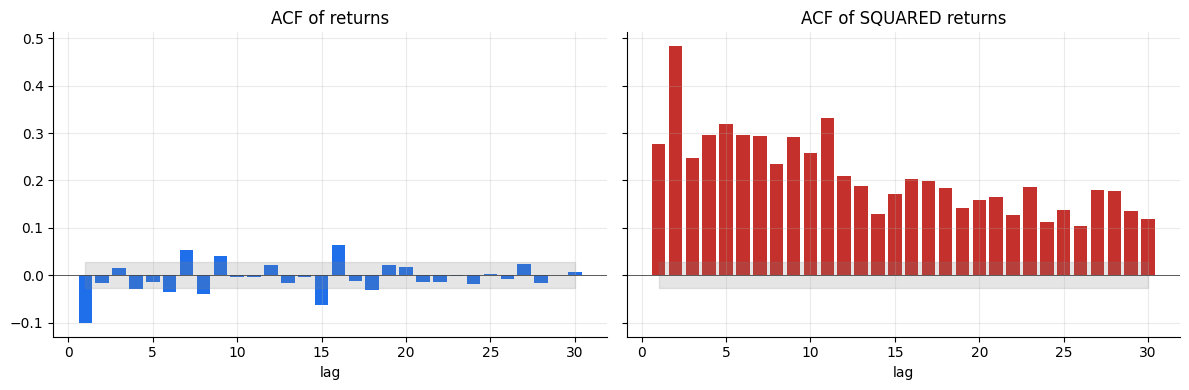

In [4]:
ac_r = acf(spy, nlags=30)
ac_r2 = acf(spy**2, nlags=30)
lags = np.arange(1, 31)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
a1.bar(lags, ac_r.values, color='#1f6feb'); a1.axhline(0, color='#444', lw=0.6)
a1.fill_between(lags, ac_r.lower_ci, ac_r.upper_ci, color='gray', alpha=0.2)
a1.set_title('ACF of returns'); a1.set_xlabel('lag')
a2.bar(lags, ac_r2.values, color='#c4302b'); a2.axhline(0, color='#444', lw=0.6)
a2.fill_between(lags, ac_r2.lower_ci, ac_r2.upper_ci, color='gray', alpha=0.2)
a2.set_title('ACF of SQUARED returns'); a2.set_xlabel('lag')
plt.tight_layout(); plt.show()


## 2. Fit GARCH(1,1)

`GARCH(p, q).fit(returns)` maximises the Gaussian log-likelihood and returns a
`GARCHFitResult` carrying the parameters, the full conditional-variance path
`sigma2`, standardised residuals, and information criteria.

Two numbers summarise the fit:

* **Persistence** $\alpha+\beta$ — how slowly shocks decay. Daily equity
  indices sit around **0.95–0.99**: volatility is very sticky.
* **Unconditional variance** $\bar\sigma^2 = \omega/(1-\alpha-\beta)$ — the
  long-run level the forecast reverts to.


In [5]:
g = GARCH(1, 1)
res = g.fit(spy)
print(res)
print(f'\nlong-run annualised vol = {np.sqrt(res.unconditional_var) * ANNUAL:.1f}%')


GARCH(1,1)  n_obs=5031
  μ        = 0.0390285
  ω        = 0.0284102
  α_1      = 0.133085
  β_1      = 0.843101
  log_lik  = -6665.7514
  AIC=13339.5028  BIC=13365.5963
  persistence = 0.9762  σ²_∞ = 1.19302

long-run annualised vol = 17.3%


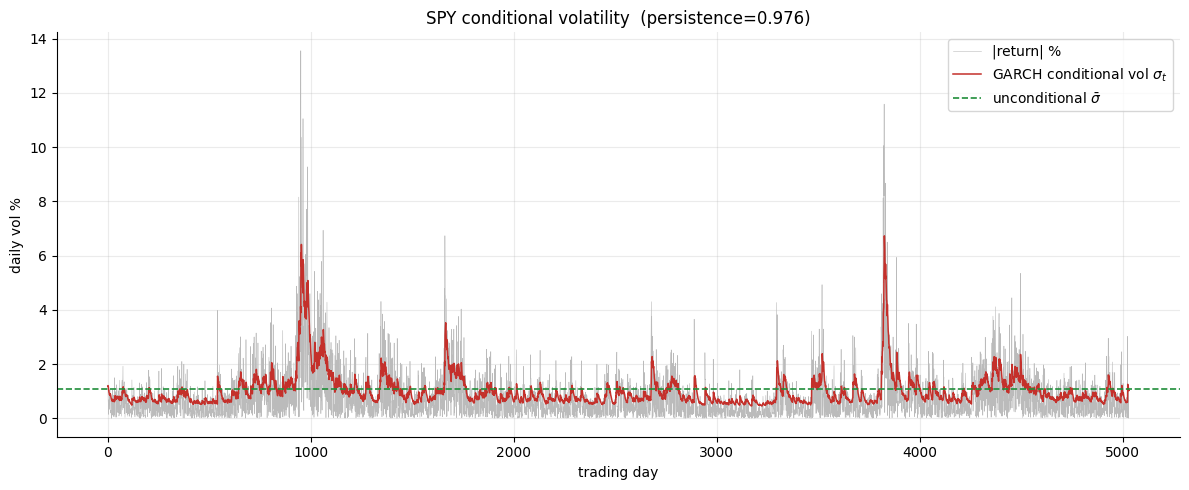

In [6]:
cond_vol = np.sqrt(res.sigma2)
fig, ax = plt.subplots()
ax.plot(np.abs(spy), color='#bbb', lw=0.4, label='|return| %')
ax.plot(cond_vol, color='#c4302b', lw=1.1, label='GARCH conditional vol $\\sigma_t$')
ax.axhline(np.sqrt(res.unconditional_var), color='#1f8e3a', ls='--', lw=1.2,
           label='unconditional $\\bar\\sigma$')
ax.set_title(f'SPY conditional volatility  (persistence={res.persistence:.3f})')
ax.set_ylabel('daily vol %'); ax.set_xlabel('trading day'); ax.legend()
plt.tight_layout(); plt.show()


### Did GARCH whiten the magnitude?

If the model is adequate, the **standardised residuals** $z_t=\varepsilon_t/\sigma_t$
should have no remaining ARCH structure — the squared-$z$ ARCH-LM p-value should
jump from "reject" to "fail to reject".


In [7]:
lm0, p0 = arch_lm(spy, lags=12)
lm1, p1 = arch_lm(res.std_residuals, lags=12)
print(f'ARCH-LM on raw returns      : LM={lm0:7.1f}  p={p0:.2e}')
print(f'ARCH-LM on std. residuals   : LM={lm1:7.1f}  p={p1:.3f}   <- clustering absorbed')
print(f'kurtosis of z_t = {((res.std_residuals**4).mean() / (res.std_residuals**2).mean()**2):.2f}'
      '  (3 = Gaussian; >3 means fat tails remain)')


ARCH-LM on raw returns      : LM= 1603.3  p=0.00e+00
ARCH-LM on std. residuals   : LM=   14.7  p=0.257   <- clustering absorbed
kurtosis of z_t = 5.22  (3 = Gaussian; >3 means fat tails remain)


## 3. Proof it works — recover known parameters

The cleanest test of an estimator: **simulate** data from a process with *known*
coefficients, then fit and check we get them back. Here we hand-roll a
GARCH(1,1) recursion with $(\omega,\alpha,\beta)=(0.02,0.10,0.85)$ —
persistence 0.95 — and refit with `GARCH(1, 1, mean='zero')`.


In [8]:
TRUE = dict(omega=0.02, alpha=0.10, beta=0.85)
n = 8000
rng = np.random.default_rng(123)
eps = np.zeros(n); s2 = np.empty(n)
s2[0] = TRUE['omega'] / (1 - TRUE['alpha'] - TRUE['beta'])
z = rng.standard_normal(n)
for t in range(1, n):
    s2[t] = TRUE['omega'] + TRUE['alpha'] * eps[t-1]**2 + TRUE['beta'] * s2[t-1]
    eps[t] = np.sqrt(s2[t]) * z[t]

fit = GARCH(1, 1, mean='zero').fit(eps)
print(f"{'param':>6} {'true':>8} {'estimated':>10}")
for name, true_v, est in [('omega', TRUE['omega'], fit.omega),
                          ('alpha', TRUE['alpha'], float(fit.alpha[0])),
                          ('beta',  TRUE['beta'],  float(fit.beta[0]))]:
    print(f'{name:>6} {true_v:8.4f} {est:10.4f}')
print(f'\npersistence  true={TRUE["alpha"]+TRUE["beta"]:.3f}  est={fit.persistence:.3f}')


 param     true  estimated
 omega   0.0200     0.0222
 alpha   0.1000     0.0924
  beta   0.8500     0.8508

persistence  true=0.950  est=0.943


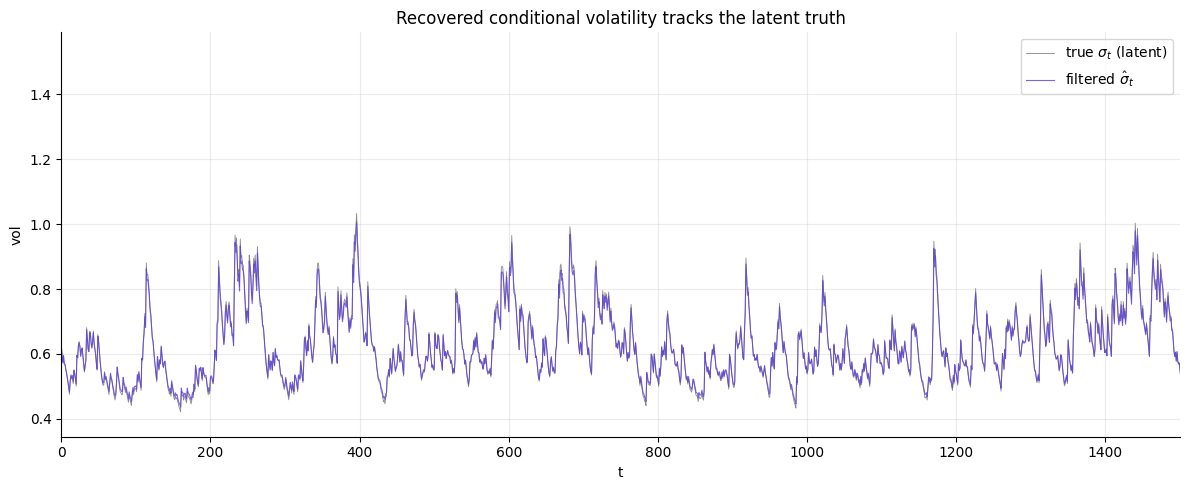

In [9]:
fig, ax = plt.subplots()
ax.plot(np.sqrt(s2), color='#888', lw=0.6, label='true $\\sigma_t$ (latent)')
ax.plot(np.sqrt(fit.sigma2), color='#5b3fd8', lw=0.8, alpha=0.8, label='filtered $\\hat\\sigma_t$')
ax.set_title('Recovered conditional volatility tracks the latent truth')
ax.set_xlim(0, 1500); ax.set_ylabel('vol'); ax.set_xlabel('t'); ax.legend()
plt.tight_layout(); plt.show()


## 4. The leverage effect

For equities, a **down** move raises future volatility more than an **up** move
of the same size (falling prices raise leverage and fear). Symmetric GARCH
can't see this. Two asymmetric extensions can:

* **GJR-GARCH** adds a term that only switches on after negative shocks; a
  positive $\gamma$ is the leverage signature.
* **EGARCH** models $\log\sigma^2$, so positivity is automatic. Its
  asymmetry coefficient $\alpha$ goes **negative** when bad news dominates.


In [10]:
gjr = GJR(1, 1).fit(spy)
eg = EGARCH(1, 1).fit(spy)
print('GJR  :', f'alpha={float(gjr.alpha[0]):.4f}  gamma(leverage)={float(gjr.gamma[0]):.4f}',
      f'beta={float(gjr.beta[0]):.4f}')
print('EGARCH:', f'alpha(asym)={float(eg.alpha[0]):+.4f}  gamma(size)={float(eg.gamma[0]):.4f}',
      f'beta={float(eg.beta[0]):.4f}')
print(f'\nGJR gamma>0 and EGARCH alpha<0 both say: negative shocks raise vol more.')


GJR  : alpha=0.0116  gamma(leverage)=0.2042 beta=0.8579
EGARCH: alpha(asym)=-0.1546  gamma(size)=0.1824 beta=0.9653

GJR gamma>0 and EGARCH alpha<0 both say: negative shocks raise vol more.


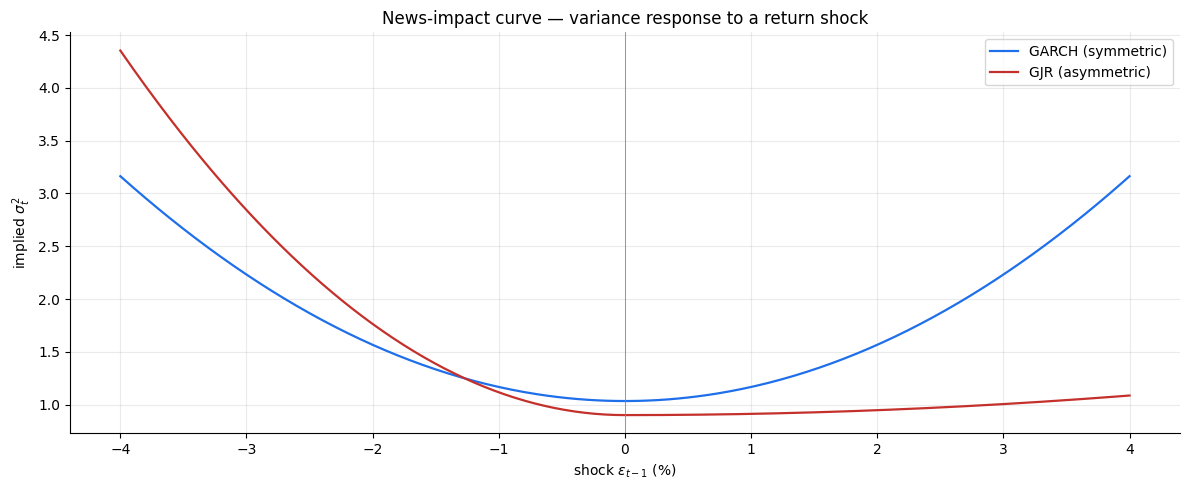

In [11]:
# News-impact curve: next-period variance response to a shock of size eps (GJR)
shock = np.linspace(-4, 4, 401)
ni_garch = res.omega + float(res.alpha[0]) * shock**2 + float(res.beta[0]) * res.unconditional_var
ni_gjr = (gjr.omega + (float(gjr.alpha[0]) + (shock < 0) * float(gjr.gamma[0])) * shock**2
          + float(gjr.beta[0]) * gjr.unconditional_var)
fig, ax = plt.subplots()
ax.plot(shock, ni_garch, color='#1f6feb', lw=1.6, label='GARCH (symmetric)')
ax.plot(shock, ni_gjr, color='#c4302b', lw=1.6, label='GJR (asymmetric)')
ax.axvline(0, color='#888', lw=0.6)
ax.set_title('News-impact curve — variance response to a return shock')
ax.set_xlabel('shock $\\varepsilon_{t-1}$ (%)'); ax.set_ylabel('implied $\\sigma_t^2$'); ax.legend()
plt.tight_layout(); plt.show()


## 5. Forecasting the variance term structure

`forecast(h)` returns $h$-step-ahead **variance** forecasts. For GARCH the
closed-form recursion mean-reverts geometrically to $\bar\sigma^2$ at rate
$(\alpha+\beta)$ — high persistence ⇒ slow reversion. From a calm start the
term structure slopes **up**; from a turbulent start it slopes **down**.


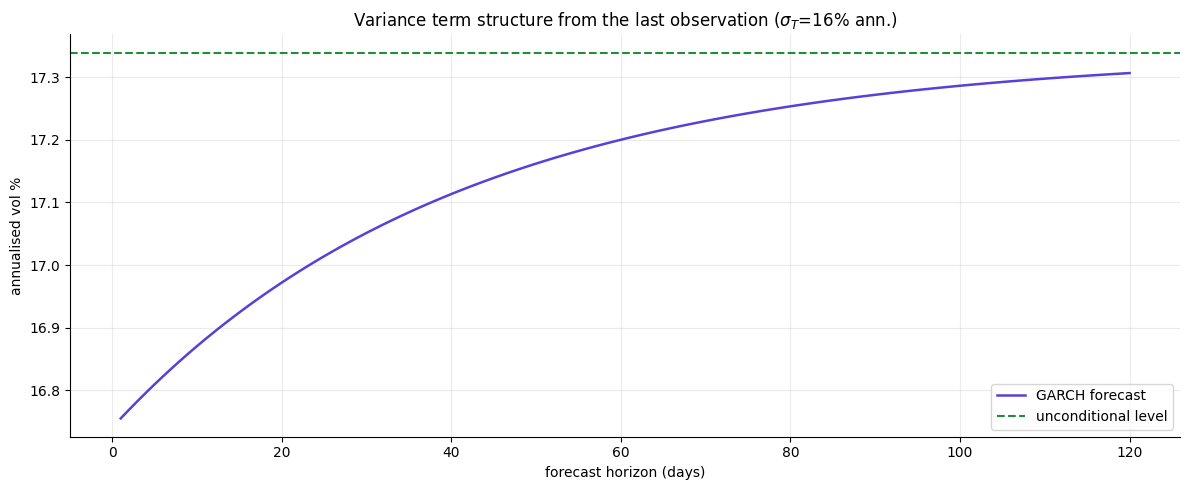

In [12]:
h = 120
fc = g.forecast(h)                       # variance, daily
fc_vol_ann = np.sqrt(fc) * ANNUAL
unc_vol_ann = np.sqrt(res.unconditional_var) * ANNUAL
fig, ax = plt.subplots()
ax.plot(np.arange(1, h+1), fc_vol_ann, color='#5b3fd8', lw=1.8, label='GARCH forecast')
ax.axhline(unc_vol_ann, color='#1f8e3a', ls='--', label='unconditional level')
ax.set_title(f'Variance term structure from the last observation '
             f'($\\sigma_T$={np.sqrt(res.sigma2[-1])*ANNUAL:.0f}% ann.)')
ax.set_xlabel('forecast horizon (days)'); ax.set_ylabel('annualised vol %'); ax.legend()
plt.tight_layout(); plt.show()


## 6. EWMA and a model bake-off

**EWMA** (RiskMetrics, $\lambda=0.94$) is the integrated-GARCH special case
with $\omega=0,\,\alpha=1-\lambda,\,\beta=\lambda$ — no estimation, just a
decay. It tracks vol well but, lacking $\omega$, never mean-reverts.

We then rank GARCH / EGARCH / GJR by **AIC and BIC** (lower is better). For
equity indices the asymmetric models almost always win — the leverage effect is
real and worth its extra parameter.


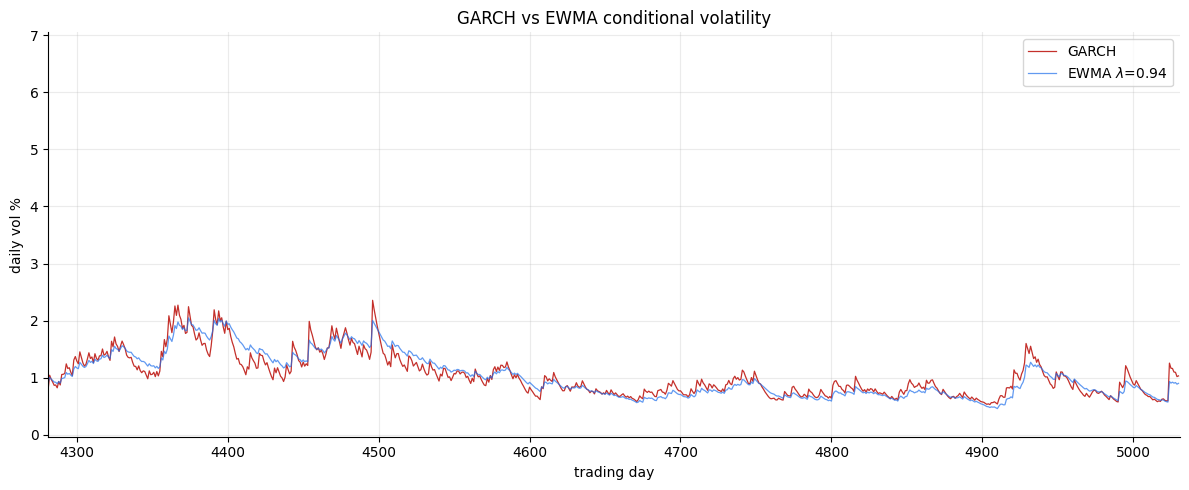

model        log_lik         AIC         BIC
GARCH        -6665.8     13339.5     13365.6
EGARCH       -6559.5     13128.9     13161.5
GJR          -6572.1     13154.3     13186.9


In [13]:
ewma = EWMA(lam=0.94).fit(spy)
fig, ax = plt.subplots()
ax.plot(np.sqrt(res.sigma2), color='#c4302b', lw=0.9, label='GARCH')
ax.plot(np.sqrt(ewma.sigma2), color='#1f6feb', lw=0.9, alpha=0.7, label='EWMA $\\lambda$=0.94')
ax.set_title('GARCH vs EWMA conditional volatility'); ax.set_xlim(len(spy)-750, len(spy))
ax.set_ylabel('daily vol %'); ax.set_xlabel('trading day'); ax.legend()
plt.tight_layout(); plt.show()

print(f"{'model':<8}{'log_lik':>12}{'AIC':>12}{'BIC':>12}")
for name, r in [('GARCH', res), ('EGARCH', eg), ('GJR', gjr)]:
    print(f'{name:<8}{r.log_lik:>12.1f}{r.aic:>12.1f}{r.bic:>12.1f}')


## 7. DCC — time-varying correlation

Risk lives in **co-movement**, not just single-asset vol. Engle's **DCC-GARCH**
estimates this in two stages: a univariate GARCH per asset, then a dynamic
correlation recursion on the standardised residuals. The pay-off is a
$R_t$ path — correlation that *moves*.

The classic result: the **stock–bond correlation** (SPY vs TLT) is usually
negative (bonds hedge stocks) but spikes toward zero or positive in liquidity
crises, exactly when you most need the diversification.


DCC-GARCH  k=3  n_obs=5031
  a=0.0449  b=0.9243  a+b=0.9692
  log_lik=-19471.4310  AIC=38970.8620  BIC=39062.1892


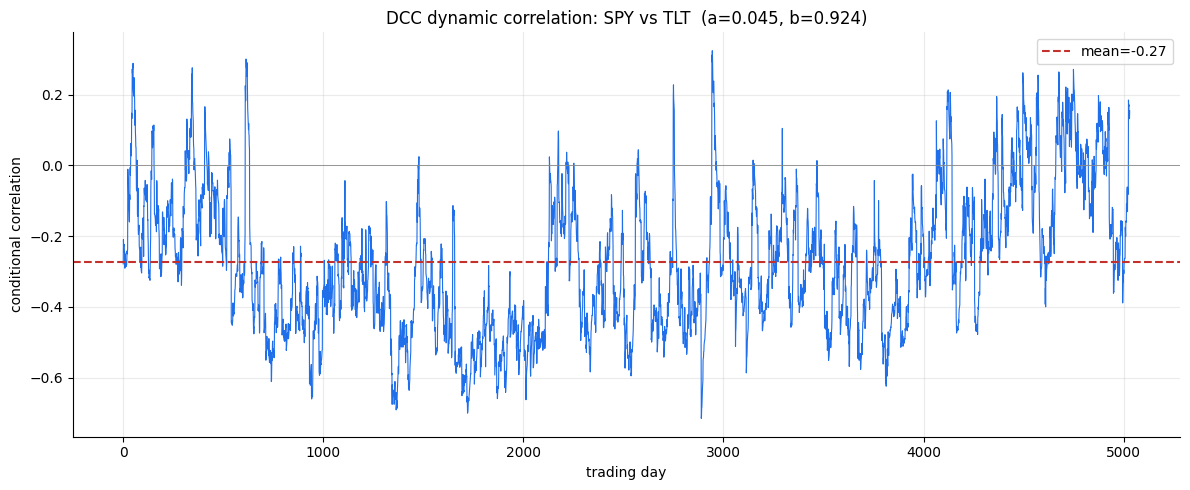

In [14]:
dcc = DCC().fit(rets)             # all columns: SPY, TLT, GLD
print(dcc)
i, j = 0, 1                          # SPY vs TLT
corr_ij = dcc.R[:, i, j]
fig, ax = plt.subplots()
ax.plot(corr_ij, color='#1f6feb', lw=0.8)
ax.axhline(corr_ij.mean(), color='#c4302b', ls='--', label=f'mean={corr_ij.mean():+.2f}')
ax.axhline(0, color='#888', lw=0.6)
ax.set_title(f'DCC dynamic correlation: {tickers[i]} vs {tickers[j]}  (a={dcc.a:.3f}, b={dcc.b:.3f})')
ax.set_ylabel('conditional correlation'); ax.set_xlabel('trading day'); ax.legend()
plt.tight_layout(); plt.show()


## 8. Hand-off — `GARCHVolTargetStrategy`

The headline application of conditional vol is **volatility targeting**: scale a
trend position by $\text{target\_vol}/\hat\sigma_t$ so realised PnL volatility
stays roughly constant across regimes. `GARCHVolTargetStrategy` wires an EMA
trend signal to a rolling GARCH forecast and does exactly this. It consumes a
**price** series (not returns), so we rebuild prices from the returns above.


GARCH Vol-Target Summary
  Sharpe (ann.)  : 0.3485
  Total return   : 71.56%
  Max drawdown   : -24.92%
  Realised vol   : 10.29%
  Avg |position| : 0.709


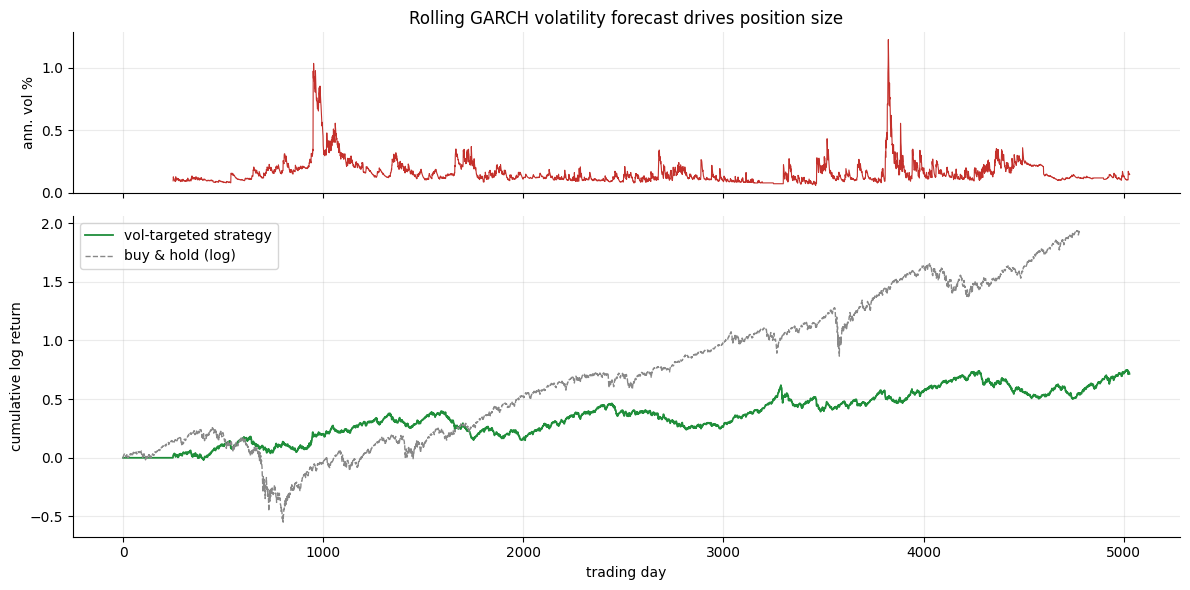

In [15]:
from qufin.strategies import GARCHVolTargetStrategy, GARCHVolTargetParams

prices = 100.0 * np.exp(np.cumsum(spy / 100.0))     # reconstruct a price path
strat = GARCHVolTargetStrategy(GARCHVolTargetParams(target_vol_ann=0.10, refit_every=50))
out = strat.run(prices)
print(out.summary())

fig, (axv, axe) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 2], figsize=(12, 6))
axv.plot(out.sigma_daily * ANNUAL, color='#c4302b', lw=0.8); axv.set_ylabel('ann. vol %')
axv.set_title('Rolling GARCH volatility forecast drives position size')
axe.plot(np.nancumsum(out.log_returns), color='#1f8e3a', lw=1.3, label='vol-targeted strategy')
axe.plot(np.cumsum(spy[strat.params.warmup:] / 100.0), color='#888', lw=1.0, ls='--',
         label='buy & hold (log)')
axe.set_ylabel('cumulative log return'); axe.set_xlabel('trading day'); axe.legend()
plt.tight_layout(); plt.show()


## What next?

* **Fat tails.** The standardised residuals are still leptokurtic — refit the
  likelihood under a Student-$t$ innovation for honest VaR/CVaR.
* **Vol-of-vol via Monte Carlo.** `GARCH.forecast(h, n_paths=...)` and the
  EGARCH/GJR Monte-Carlo paths give the *distribution* of future variance, not
  just its mean.
* **Risk budgeting.** Feed the DCC $H_t$ covariance path into
  `qufin.portfolio.optimize` for a conditionally-rebalanced minimum-variance
  book.
* **Regimes.** Pair the conditional-vol estimate with a Markov-switching mean
  model (`qufin.timeseries.MarkovSwitchingAR`) to separate "calm drift" from
  "crisis" states.
